In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.api as sm
import statsmodels.formula.api as smf
from sklearn.model_selection import train_test_split

In [2]:
# load the dataset
df = pd.read_csv('../additional_material/datasets/week12/wine_development(in).csv')
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,color,wine_id
0,5.8,0.31,0.32,4.5,0.024,28.0,94.0,0.98906,3.25,0.52,13.7,7,white,1198
1,6.3,0.13,0.42,1.1,0.043,63.0,146.0,0.99066,3.13,0.72,11.2,7,white,3409
2,8.2,0.30,0.44,12.4,0.043,52.0,154.0,0.99452,3.04,0.33,12.0,6,white,4789
3,9.4,0.17,0.55,1.6,0.049,14.0,94.0,0.99490,3.02,0.61,10.3,6,white,3054
4,5.3,0.30,0.16,4.2,0.029,37.0,100.0,0.99050,3.30,0.36,11.8,8,white,2812


/var/folders/x4/k7_nkprd0q3bw82ysv293f4h0000gn/T/ipykernel_64569/1899639063.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='color', y='density', palette='Set2', ax=axes[0])
/var/folders/x4/k7_nkprd0q3bw82ysv293f4h0000gn/T/ipykernel_64569/1899639063.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='color', y='residual sugar', palette='Set2', ax=axes[1])


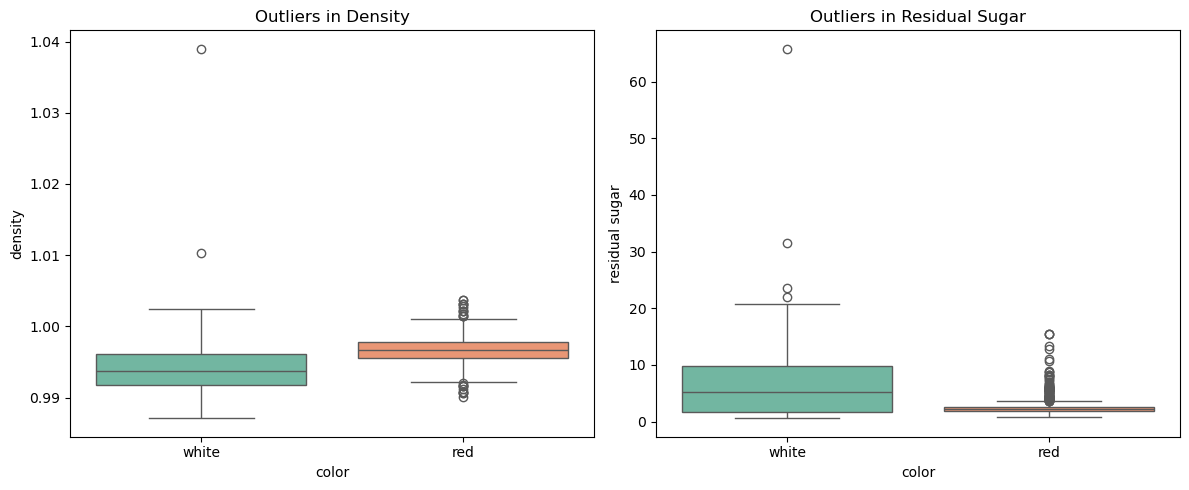

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Plot Density
sns.boxplot(data=df, x='color', y='density', palette='Set2', ax=axes[0])
axes[0].set_title('Outliers in Density')

# Plot Residual Sugar
sns.boxplot(data=df, x='color', y='residual sugar', palette='Set2', ax=axes[1])
axes[1].set_title('Outliers in Residual Sugar')

plt.tight_layout()
plt.show()

In [4]:
df.duplicated().sum()

np.int64(0)

In [5]:
df.isnull().sum()

fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
color                   0
wine_id                 0
dtype: int64

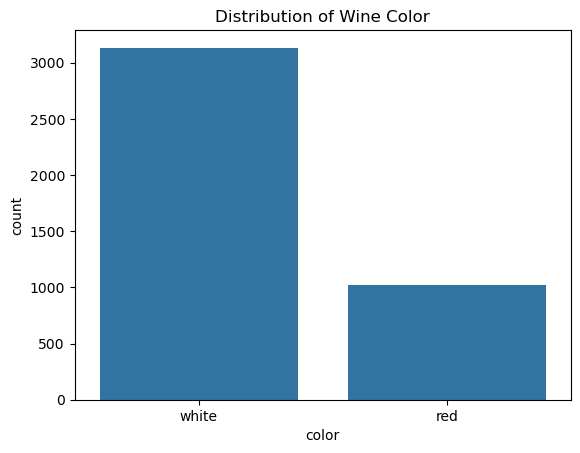

In [6]:
#plot the data to see the distribution of the target variable 'color'
sns.countplot(x='color', data=df)
plt.title('Distribution of Wine Color')
plt.show()

In [7]:
#get the percentage of each color
color_counts = df['color'].value_counts(normalize=True) * 100
print(color_counts)

color
white    75.390907
red      24.609093
Name: proportion, dtype: float64


In [8]:
df.drop(columns=['wine_id'], inplace=True)

In [9]:
df.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,4157.000000,4157.000000,4157.000000,4157.000000,4157.000000,4157.000000,4157.000000,4157.000000,4157.000000,4157.000000,4157.000000,4157.000000
mean,7.208119,0.339251,0.318807,5.400036,0.056000,30.415684,115.484845,0.994671,3.219584,0.529909,10.491434,5.822228
std,1.298362,0.166326,0.144223,4.733309,0.034769,17.991538,56.849564,0.003016,0.159991,0.145713,1.193001,0.882078
min,3.900000,0.080000,0.000000,0.600000,0.012000,1.000000,6.000000,0.987110,2.740000,0.220000,8.000000,3.000000
25%,6.400000,0.230000,0.250000,1.800000,0.038000,17.000000,77.000000,0.992300,3.110000,0.430000,9.500000,5.000000
50%,7.000000,0.290000,0.310000,3.000000,0.047000,29.000000,118.000000,0.994800,3.210000,0.510000,10.300000,6.000000
75%,7.700000,0.400000,0.390000,8.100000,0.065000,41.000000,155.000000,0.996920,3.320000,0.600000,11.300000,6.000000
max,15.900000,1.580000,1.660000,65.800000,0.611000,289.000000,440.000000,1.038980,3.900000,1.950000,14.900000,9.000000


### Spliting Data


In [10]:
# Split the data into training and testing sets
y=df.pop('color')
X_train, X_test, y_train, y_test = train_test_split(df, y, test_size=0.2, stratify=y, random_state=42)
# print the shape of the training and testing sets
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

X_train shape: (3325, 12)
X_test shape: (832, 12)


In [11]:
# number classes of the target variable in the training and test set
print("Training set class distribution:\n", y_train.value_counts())
print("Test set class distribution:\n", y_test.value_counts())

Training set class distribution:
 color
white    2507
red       818
Name: count, dtype: int64
Test set class distribution:
 color
white    627
red      205
Name: count, dtype: int64


#### Creating null model or baseline

In [12]:
from sklearn.dummy import DummyClassifier
from sklearn.metrics import f1_score,accuracy_score
null_model = DummyClassifier(strategy="most_frequent")
null_model.fit(X_train, y_train)
y_pred_null = null_model.predict(X_test)
null_accuracy = accuracy_score(y_test, y_pred_null)
null_f1 = f1_score(y_test, y_pred_null, average='macro')
print("Null Model Accuracy:", null_accuracy)
print("Null Model F1 Score:", null_f1)

Null Model Accuracy: 0.7536057692307693
Null Model F1 Score: 0.4297464016449623


### Radial Basis Svm

In [13]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
rb_svm = Pipeline([
    ('scaler', StandardScaler()),
    ('svc', SVC(kernel='rbf', C=1.0, gamma='scale', random_state=42))
]
)
rb_svm.fit(X_train, y_train)
y_pred_rb = rb_svm.predict(X_test)
rb_accuracy = accuracy_score(y_test, y_pred_rb)
rb_f1 = f1_score(y_test, y_pred_rb, average='macro')
print("RBF SVM Accuracy:", rb_accuracy)
print("RBF SVM F1 Score:", rb_f1)

RBF SVM Accuracy: 0.9963942307692307
RBF SVM F1 Score: 0.9951372992139024


In [14]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'svc__C': [0.001, 0.1, 1, 10, 100],
    'svc__gamma': ['scale', 'auto', 0.01, 0.1, 1]
}

grid_search = GridSearchCV(
    estimator=rb_svm,     # your pipeline
    param_grid=param_grid,
    cv=5,
    scoring='f1_macro',
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

best_params = grid_search.best_params_
print("Best Parameters:", best_params)


Best Parameters: {'svc__C': 100, 'svc__gamma': 0.01}


In [15]:
best_model = grid_search.best_estimator_
y_pred_test = best_model.predict(X_test)
test_accuracy = accuracy_score(y_test, y_pred_test)
test_f1 = f1_score(y_test, y_pred_test, average='macro')
print("Tuned RBF SVM Test Accuracy:", test_accuracy)
print("Tuned RBF SVM Test F1 Score:", test_f1)

Tuned RBF SVM Test Accuracy: 0.9963942307692307
Tuned RBF SVM Test F1 Score: 0.9951372992139024


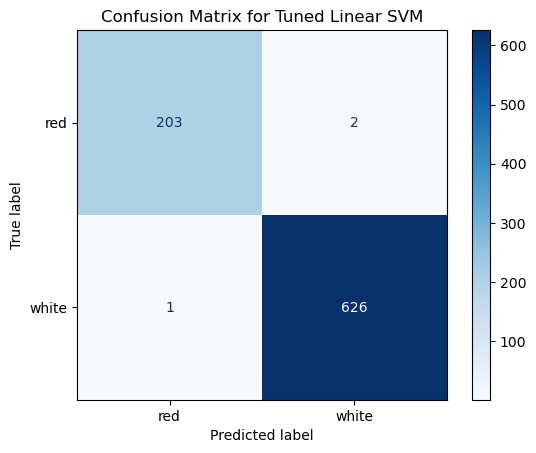

In [16]:
# confusion matrix for the best linear SVM model
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
cm = confusion_matrix(y_test, y_pred_test, labels=best_model.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=best_model.classes_)
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix for Tuned Linear SVM')
plt.show()

In [17]:
from sklearn.metrics import classification_report
report_dict = classification_report(
    y_test, 
    y_pred_test, 
    output_dict=True   
)
report_df = pd.DataFrame(report_dict).transpose()
report_df.round(3)

,precision,recall,f1-score,support
red,0.995,0.990,0.993,205.000
white,0.997,0.998,0.998,627.000
accuracy,0.996,0.996,0.996,0.996
macro avg,0.996,0.994,0.995,832.000
weighted avg,0.996,0.996,0.996,832.000


### Linear Svm

In [18]:
linear_svm = Pipeline([
    ('scaler', StandardScaler()),
    ('svc', SVC(kernel='linear', C=1.0, random_state=42))
]
)
linear_svm.fit(X_train, y_train)
y_pred_linear = linear_svm.predict(X_test)
linear_accuracy = accuracy_score(y_test, y_pred_linear)
linear_f1 = f1_score(y_test, y_pred_linear, average='macro')
print("Linear SVM Accuracy:", linear_accuracy)
print("Linear SVM F1 Score:", linear_f1)

Linear SVM Accuracy: 0.9951923076923077
Linear SVM F1 Score: 0.9935270548877737


In [19]:
param_grid = {
    'svc__C': [0.001, 0.1, 1, 10, 100]
}

grid_search = GridSearchCV(
    estimator=linear_svm,     
    param_grid=param_grid,
    cv=5,
    scoring='f1_macro',
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

best_params = grid_search.best_params_
print("Best Parameters:", best_params)

Best Parameters: {'svc__C': 1}


In [20]:
best_model = grid_search.best_estimator_
y_pred_test = best_model.predict(X_test)
test_accuracy = accuracy_score(y_test, y_pred_test)
test_f1 = f1_score(y_test, y_pred_test, average='macro')
print("Tuned RBF SVM Test Accuracy:", test_accuracy)
print("Tuned RBF SVM Test F1 Score:", test_f1)

Tuned RBF SVM Test Accuracy: 0.9951923076923077
Tuned RBF SVM Test F1 Score: 0.9935270548877737


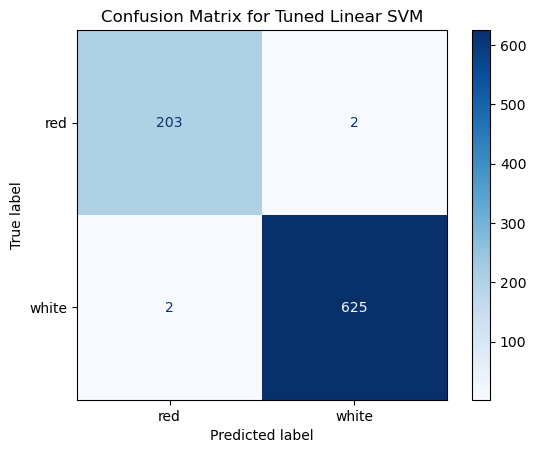

In [21]:
# confusion matrix for the best linear SVM model
cm = confusion_matrix(y_test, y_pred_test, labels=best_model.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=best_model.classes_)
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix for Tuned Linear SVM')
plt.show()

In [22]:
report_dict = classification_report(
    y_test, 
    y_pred_test, 
    output_dict=True   
)
report_df = pd.DataFrame(report_dict).transpose()
report_df.round(3)

,precision,recall,f1-score,support
red,0.990,0.990,0.990,205.000
white,0.997,0.997,0.997,627.000
accuracy,0.995,0.995,0.995,0.995
macro avg,0.994,0.994,0.994,832.000
weighted avg,0.995,0.995,0.995,832.000


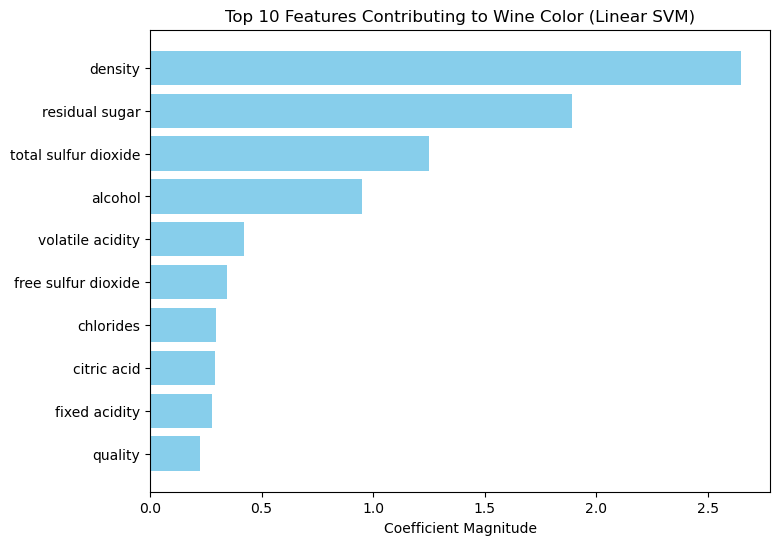

In [23]:
# Create dataframe of coefficients
coef_df = pd.DataFrame({
    "feature": X_train.columns,
    "coefficient": best_model.named_steps["svc"].coef_[0]
})

# Select top 10 by absolute value
top10 = coef_df.reindex(coef_df['coefficient'].abs().sort_values(ascending=False).index).head(10)

# Take absolute value for plotting
top10['abs_coefficient'] = top10['coefficient'].abs()

# Plot horizontal bar chart
plt.figure(figsize=(8,6))
plt.barh(top10['feature'], top10['abs_coefficient'], color='skyblue')
plt.xlabel('Coefficient Magnitude')
plt.title('Top 10 Features Contributing to Wine Color (Linear SVM)')
plt.gca().invert_yaxis()  # largest coefficient on top
plt.show()


- a PCA of all, or scatterplot of  two e.g. most important features could give you some insights as well
- some visualizations
- use the best_model which is the linear_svm to evaluate the model performance on holdout 

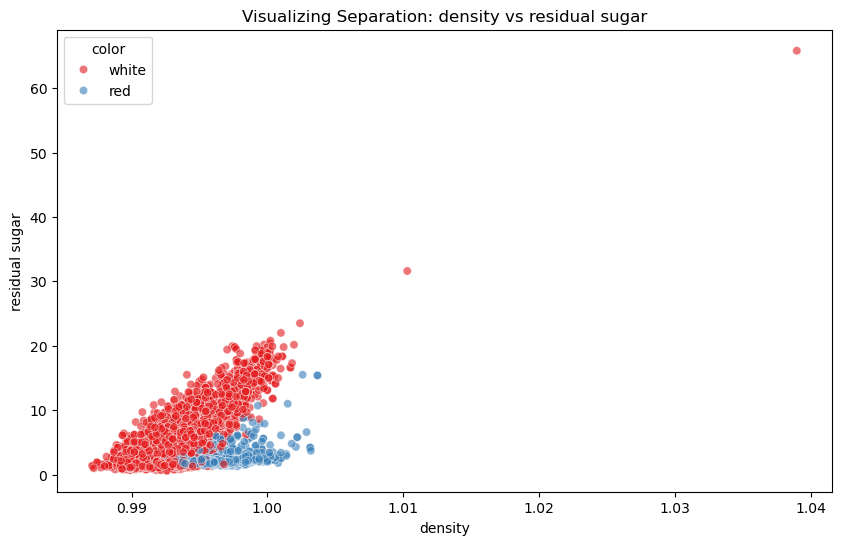

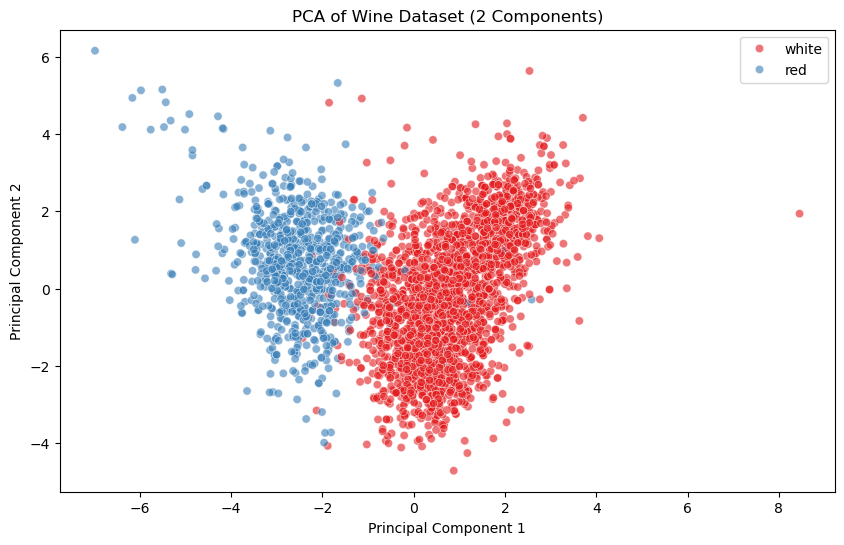

In [24]:
# Scatterplot of the Top 2 Features
# (Replace these strings with the actual top 2 names from your bar chart if they differ)
feat1 = 'density'
feat2 = 'residual sugar'

plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x=feat1, y=feat2, hue=y, alpha=0.6, palette='Set1')
plt.title(f'Visualizing Separation: {feat1} vs {feat2}')
plt.show()

# 2. PCA (Principal Component Analysis)
# This smashes all 12 dimensions down to 2 so we can see the "Big Picture"
from sklearn.decomposition import PCA

# We need to scale the data first (just like the SVM does)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_train)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(10, 6))
# We perform a trick to color the points by the original labels (y_train)
# Note: reset_index is needed if y_train shuffled indices
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=y_train.values, alpha=0.6, palette='Set1')
plt.title('PCA of Wine Dataset (2 Components)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.show()

Class Balance:
 is_excellent
1    0.635073
0    0.364927
Name: proportion, dtype: float64

--- Quality Prediction Report ---
              precision    recall  f1-score   support

           0       0.74      0.64      0.69       304
           1       0.81      0.87      0.84       528

    accuracy                           0.79       832
   macro avg       0.77      0.76      0.76       832
weighted avg       0.78      0.79      0.78       832



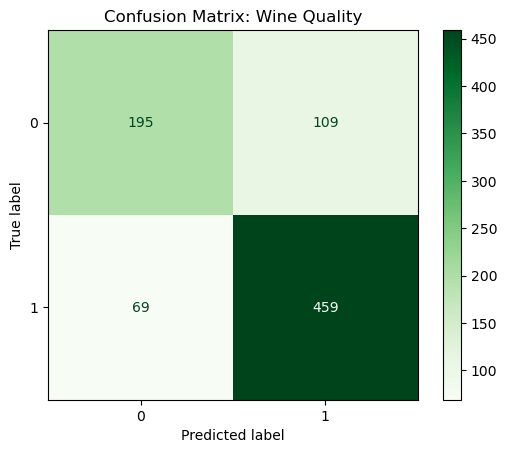

In [26]:
# Reload data to be safe (ensure we have all columns back)
df_bonus = pd.read_csv('../additional_material/datasets/week12/wine_development(in).csv')

# Create the new Target Label
# 1 = Excellent (Quality >= 6), 0 = Not Excellent
df_bonus['is_excellent'] = (df_bonus['quality'] >= 6).astype(int)

# Check the balance (Is it harder to find excellent wines?)
print("Class Balance:\n", df_bonus['is_excellent'].value_counts(normalize=True))

# Define Features (X) and Target (y)
# We drop 'quality' (because it IS the answer) and 'is_excellent' (target)
# We also drop 'color' and 'wine_id' to keep it to chemical numeric features
X_bonus = df_bonus.drop(columns=['quality', 'is_excellent', 'color', 'wine_id'])
y_bonus = df_bonus['is_excellent']

# Split the data (Stratified by the NEW target)
X_train_b, X_test_b, y_train_b, y_test_b = train_test_split(
    X_bonus, y_bonus, test_size=0.2, random_state=42, stratify=y_bonus
)

# Build and Train the Pipeline
quality_svm = Pipeline([
    ('scaler', StandardScaler()),
    ('svc', SVC(kernel='rbf', C=1, gamma='scale')) # Starting with RBF as quality is complex!
])

quality_svm.fit(X_train_b, y_train_b)

# Evaluate
y_pred_b = quality_svm.predict(X_test_b)
print("\n--- Quality Prediction Report ---")
print(classification_report(y_test_b, y_pred_b))


ConfusionMatrixDisplay.from_estimator(quality_svm, X_test_b, y_test_b, cmap=plt.cm.Greens)
plt.title('Confusion Matrix: Wine Quality')
plt.show()

In [28]:
#Load the Holdout Features
try:
    df_holdout_X = pd.read_csv('../additional_material/datasets/week12/wine_holdout_X(in).csv')
    print("Holdout features loaded successfully.")
    
    # Drop 'wine_id' so the columns match the training data exactly
    if 'wine_id' in df_holdout_X.columns:
        X_holdout_clean = df_holdout_X.drop(columns=['wine_id'])
    else:
        X_holdout_clean = df_holdout_X
    # -----------------------

    # Predict using your BEST model (Tuned Linear SVM)
    # The pipeline will handle the scaling automatically
    holdout_predictions = best_model.predict(X_holdout_clean)
    print("Predictions generated successfully!")
    
    # Load the Holdout Labels (The "Answer Key")
    # Only run this if/when you have the 'wine_holdout_y.csv' file
    try:
        df_holdout_y = pd.read_csv('../additional_material/datasets/week12/wine_holdout_y(in).csv')
        
        # Ensure we grab the correct column name for the labels
        # It's usually 'color', similar to the dev set
        y_true_holdout = df_holdout_y['color'] 
        
        print("\n--- Final Generalization Performance (Holdout Set) ---")
        print("Accuracy:", accuracy_score(y_true_holdout, holdout_predictions))
        print(classification_report(y_true_holdout, holdout_predictions))
        
        # Compare Internal vs External
        # (Replace 'test_accuracy' with 'linear_accuracy' if that was your var name)
        print(f"Internal Test Score: {test_accuracy:.4f}") 
        print(f"Holdout Score:       {accuracy_score(y_true_holdout, holdout_predictions):.4f}")
        
    except FileNotFoundError:
        print("Holdout labels (y) not found yet. Predictions generated but not evaluated.")

except FileNotFoundError:
    print("Holdout features (X) not found. Skipping holdout step.")
except Exception as e:
    print(f"An error occurred: {e}")

Holdout features loaded successfully.
Predictions generated successfully!

--- Final Generalization Performance (Holdout Set) ---
Accuracy: 0.9942307692307693
              precision    recall  f1-score   support

         red       0.99      0.98      0.99       256
       white       0.99      1.00      1.00       784

    accuracy                           0.99      1040
   macro avg       0.99      0.99      0.99      1040
weighted avg       0.99      0.99      0.99      1040

Internal Test Score: 0.9952
Holdout Score:       0.9942
